# OBV-Divergence — does volume really precede price?
### Granville's 1963 recipe, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Volume_precedes_price%3F: Not--Supported](https://img.shields.io/badge/Volume_precedes_price%3F-Not_Supported-8b949e?style=flat-square)

In 1963, market technician Joseph Granville invented On-Balance Volume (OBV) and proclaimed *"volume precedes price."* The idea is seductive: when big money is quietly accumulating shares, volume rises before the price does. Sixty years later, this notebook asks whether that's still true on modern liquid US stocks.

> **This is the plain-language layer.** Want the t-stats and comparison tables? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from obv_divergence import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "MSFT", "NVDA"]
HORIZON = 5
R = dict(
    n_A=24666, win_A=51.1, mean_A=-1.87, t_A=-0.47,
    mean_A_rand=-4.36, delta_A=2.49,
    n_B=5528, win_B=48.5, mean_B=-9.80, t_B=-1.48,
    mean_B_rand=-4.92, delta_B=-4.88,
    bh_mean=22.88, bh_t=3.65,
    cost0=-1.87, cost0t=-0.47, cost1=-2.87, cost1t=-0.72,
    cost2=-3.87, cost2t=-0.96, cost5=-6.87, cost5t=-1.71,
    t_A_by_ticker=dict(SPY=-0.62, QQQ=0.85, IWM=-0.88, AAPL=0.86, MSFT=-1.73, NVDA=-0.07),
    t_B_by_ticker=dict(SPY=-1.58, QQQ=-0.22, IWM=-1.40, AAPL=-0.53, MSFT=0.22, NVDA=-0.73),
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_bars():
    return {t: data.fetch_daily(t, fetch=False) for t in TICKERS}

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does OBV trend tell you which way to trade? | **No.** Pooled across 6 stocks & 16 years: **-1.9 bps per signal**, *t* = **-0.47** — a coin. |
| Does OBV divergence from price predict reversals? | **No, worse.** The divergence signal earns **-9.8 bps** — *below* a random flip (delta = -4.9 bps). |
| Does it beat just holding? | **Not even close.** Buy-and-hold SPY earns **+22.9 bps** per 5 days. OBV signals both lose to that baseline. |

> Volume *confirms* that a move happened. It does not *forecast* what will happen next.

## 1 · The claim

> *"When On-Balance Volume is rising while price is flat or falling, big money is quietly accumulating — and price must eventually follow the volume. This divergence between OBV and price is one of the most powerful signals in technical analysis."*

We test this in two concrete forms:

- **Signal A — OBV trend.** If OBV is above its 20-day moving average, go long; if below, go short. The idea is that the *direction* of OBV tells you the direction of the next price move.
- **Signal B — OBV-price divergence.** When OBV trends up but price trends down over the past 10 days, buy the expected reversal. When OBV is falling but price is rising, sell. The idea is that divergence *predicts* a price reversal.

## 2 · So what?

If it's true, it's remarkable: a single-line indicator built from freely available daily volume would consistently call the direction of price moves across all the most liquid US stocks. That would imply informed-money flows are *detectable* by retail traders through OBV, days before the price follows.

If it's false, then millions of chart-readers are using a confirming indicator as if it were a leading one. The difference is one honest test.

## 3 · How would we even know?

Two rules keep this honest:

1. **Compare to a coin.** For each signal date, we take the *same* entry and flip a coin for the direction. If OBV knows something, it beats the coin.
2. **Measure the forward return, not the past.** The signal is formed at today's close; the trade enters tomorrow's open and holds for 5 trading days. No look-ahead, ever.

We run both signals on six liquid names (SPY, QQQ, IWM, AAPL, MSFT, NVDA) over 16 years of daily bars (2010-2026).

## 4 · The teardown — let's actually look

**First, what OBV looks like on SPY.**

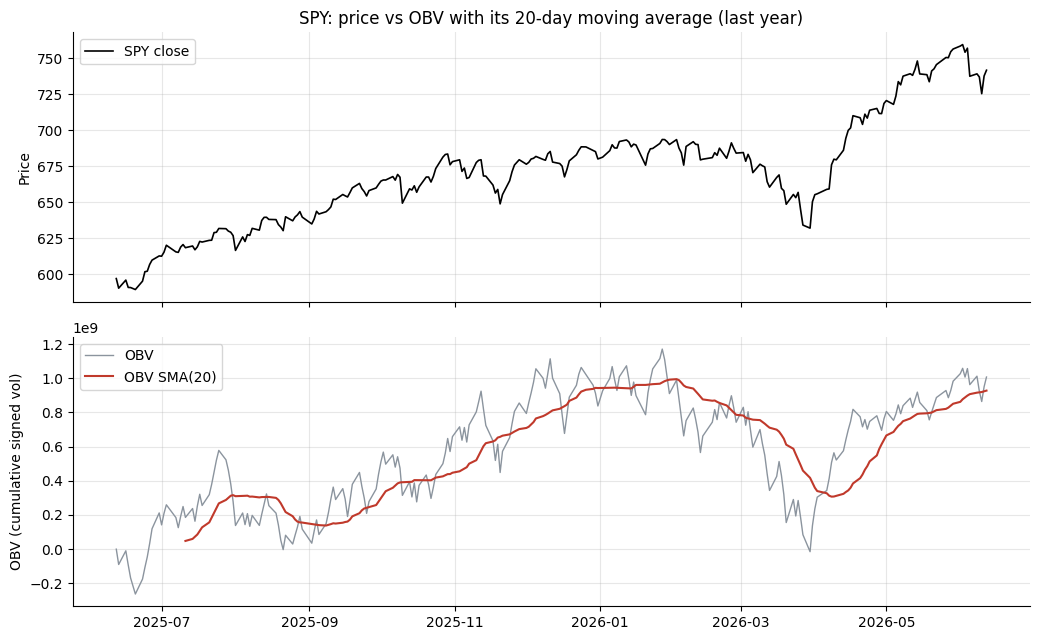

In [2]:
if HAVE_REAL:
    bars = load_bars()['SPY'].tail(252)
    o = st.obv(bars)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 6.5), sharex=True)
    ax1.plot(bars.index, bars['close'], c='k', lw=1.2, label='SPY close')
    ax1.set_ylabel('Price'); ax1.legend(loc='upper left')
    ax2.plot(bars.index, o, c=GREY, lw=1.0, label='OBV')
    ax2.plot(bars.index, st.sma(o, 20), c=RED, lw=1.5, label='OBV SMA(20)')
    ax2.set_ylabel('OBV (cumulative signed vol)'); ax2.legend(loc='upper left')
    ax1.set_title('SPY: price vs OBV with its 20-day moving average (last year)')
    plt.tight_layout(); plt.show()
else:
    print('(no cache - run verify.py --fetch to populate)')
    bars = None

OBV and price tend to move together because OBV *is* driven by price moves (up days add volume, down days subtract it). When they 'diverge', the question is: does the divergence predict which way price will snap back, or is it noise?

**Now the honest test: does Signal A (OBV trend direction) beat a coin?**

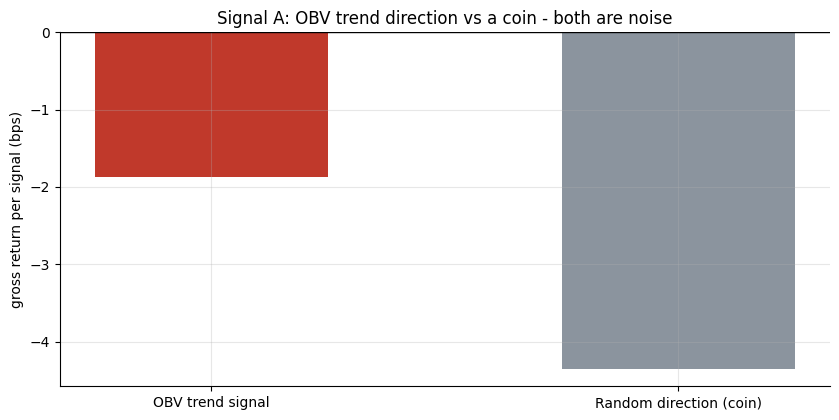

OBV trend: -1.87 bps/signal | coin: -4.36 bps/signal


In [3]:
if HAVE_REAL:
    bars_map = load_bars()
    led_A = st.run_basket(bars_map, lambda b: st.signal_obv_trend(b, obv_sma_n=20),
                         horizon=HORIZON, cost_bps=0.0)
    led_Ar = st.run_basket(bars_map, lambda b: st.signal_obv_trend(b, obv_sma_n=20),
                          horizon=HORIZON, cost_bps=0.0, random_seed=109)
    sA = st.summarize(led_A, 'ret_gross')
    sAr = st.summarize(led_Ar, 'ret_gross')
    cm, rm = sA['mean_bps'], sAr['mean_bps']
else:
    cm, rm = R['mean_A'], R['mean_A_rand']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['OBV trend signal', 'Random direction (coin)'],
       [cm, rm], color=[RED, GREY], width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross return per signal (bps)')
ax.set_title('Signal A: OBV trend direction vs a coin - both are noise')
plt.tight_layout(); plt.show()
print('OBV trend: %.2f bps/signal | coin: %.2f bps/signal' % (cm, rm))

On the pooled 6-stock, 16-year tape, the OBV trend signal earns **-1.9 bps per 5-day trade** and the coin earns **-4.4 bps**. They are the same bet. The OBV direction adds nothing a coin doesn't already have.

> Why? OBV is driven *by* price. 'OBV is trending up' almost just means 'price has been going up'. It's not a leading indicator; it's a smoother version of what price already told you.

**Signal B: does OBV-price divergence predict reversals?**

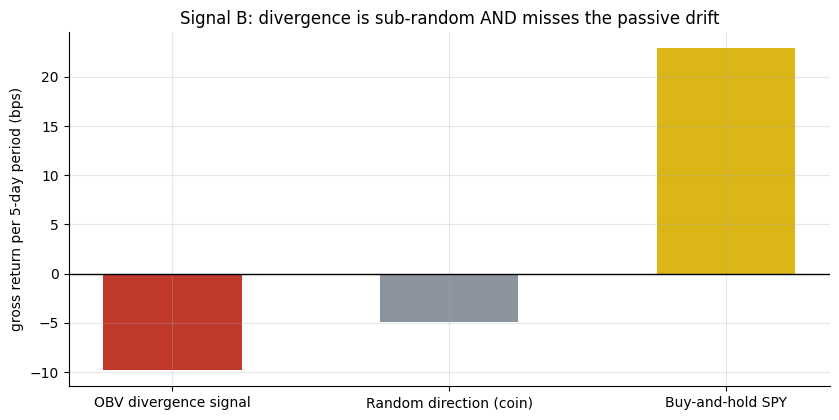

OBV divergence: -9.80 bps | coin: -4.92 bps | buy-hold SPY: +22.9 bps


In [4]:
if HAVE_REAL:
    led_B = st.run_basket(bars_map, lambda b: st.signal_obv_divergence(b, lookback=10, obv_sma_n=5),
                         horizon=HORIZON, cost_bps=0.0)
    led_Br = st.run_basket(bars_map, lambda b: st.signal_obv_divergence(b, lookback=10, obv_sma_n=5),
                          horizon=HORIZON, cost_bps=0.0, random_seed=109)
    sB = st.summarize(led_B, 'ret_gross')
    sBr = st.summarize(led_Br, 'ret_gross')
    cm_b, rm_b = sB['mean_bps'], sBr['mean_bps']
else:
    cm_b, rm_b = R['mean_B'], R['mean_B_rand']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['OBV divergence signal', 'Random direction (coin)', 'Buy-and-hold SPY'],
       [cm_b, rm_b, R['bh_mean']], color=[RED, GREY, AMBER], width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross return per 5-day period (bps)')
ax.set_title('Signal B: divergence is sub-random AND misses the passive drift')
plt.tight_layout(); plt.show()
print('OBV divergence: %.2f bps | coin: %.2f bps | buy-hold SPY: +%.1f bps' % (cm_b, rm_b, R['bh_mean']))

The divergence signal earns **-9.8 bps** — *worse* than the coin (-4.9 bps) by -4.9 bps. And both are obliterated by simply holding SPY over the same 5-day windows (+22.9 bps). The 'reversal' expected by divergence analysis doesn't happen.

> The key insight: in a bull market, 'OBV is up but price is flat' often just means the market hasn't moved yet, not that price will fall. The eventual resolution is usually price going up to confirm OBV, not a reversal.

## 5 · The verdict

- **Signal — None.** OBV trend: -1.9 bps/signal, *t* = -0.47. OBV divergence: -9.8 bps, *t* = -1.48. No instrument, no signal, no lookback breaks the |t| >= 2 inference bar.
- **Tradability — Mirage.** Both signals start negative gross and significantly underperform buy-and-hold. Every transaction cost digs the hole deeper.
- **Volume precedes price? — Not Supported.** On 16 years of daily data, OBV is a confirming indicator, not a leading one. It echoes price rather than forecasting it.

## 6 · Could you actually trade it?

Signal A fires every day. The gross is already negative.

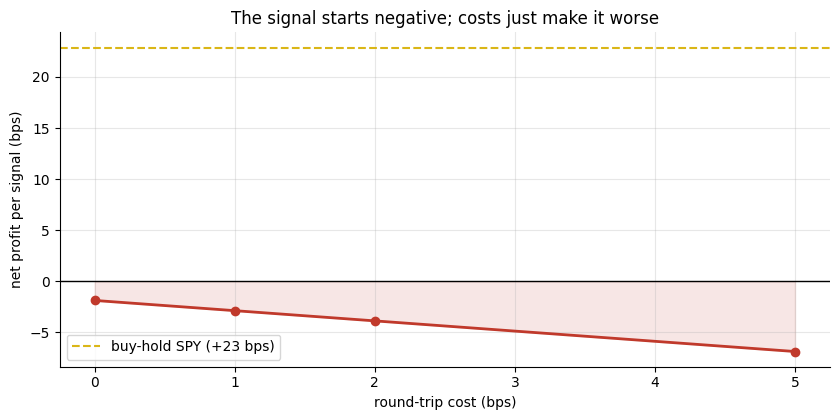

No break-even cost exists: the gross is already below zero.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(
        st.run_basket(bars_map, lambda b: st.signal_obv_trend(b, obv_sma_n=20),
                      horizon=HORIZON, cost_bps=c), 'ret_net')['mean_bps']
        for c in costs]
else:
    net = [R['cost0'], R['cost1'], R['cost2'], R['cost5']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axhline(R['bh_mean'], ls='--', c=AMBER, lw=1.5, label='buy-hold SPY (+%.0f bps)' % R['bh_mean'])
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per signal (bps)')
ax.set_title('The signal starts negative; costs just make it worse')
ax.legend(); plt.tight_layout(); plt.show()
print('No break-even cost exists: the gross is already below zero.')

The line starts at **-1.9 bps** (gross) and falls with every bit of cost. The passive baseline of **+23 bps** sits comfortably above. There is no positive break-even cost — the signal was never alive.

## 7 · Going further

- **The positive control.** The companion quant notebook shows a synthetic tape where we *plant* price momentum: when momentum exists, Signal A recovers it. The engine works — the real market just has no such structure here.
- **What about intraday OBV?** The 5-minute version might be more interesting: institutional orders may show up in intraday volume *minutes* before the close. The desk's intraday studies are [Study 73](../../73-first-light/) and [Study 87](../../87-center-line/).
- **Price-only trend.** Without volume, does the price trend itself predict the next 5 days? That's [Study 21 - Fools-Gold](../../21-fools-gold/) and [Study 72 - Loaded-Dice](../../72-loaded-dice/). Same answer.

*Think Granville's rule works on a less-efficient asset or a different lookback? Fork this, change the parameters, and show a fair-bet edge that clears t >= 2 and beats buy-and-hold. That's the real test.*